# char_11 — Is there a better way to overlap the spectra than SNV?

## Purpose

Every cross-source comparison in this folder runs through the same preprocessing chain:
**crop → linear detrend → SNV**. SNV is doing a lot of load-bearing work, so the obvious
question is whether some other way of putting bulk charcoal and filter aerosol on a
common footing would work better — vector normalization, area normalization, normalizing
to a reference band, MSC/EMSC, or derivative spectra.

The answer has two halves, and the first one is surprising:

1. **For most of the alternatives, the question is empty.** Under Pearson correlation —
   the metric all the analogue matching uses — SNV, vector normalization, area
   normalization, band normalization and even *no normalization at all* are
   *mathematically identical*. They are not competing options; they are the same option
   written five ways. (MSC is the one near-miss, for a reason worth seeing.)
2. **The choices that genuinely differ** are the ones that are not a per-spectrum affine
   rescaling: baseline/slope removal, EMSC, and derivative spectra. Those are benchmarked
   here against an objective criterion that never looks at Addis — and one of them
   materially changes a headline conclusion.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))
sys.path.insert(0, str((Path("..") / "ftir_ec_phase3" / "scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from charcoal_spectra import load_all, snv, resample, detrend, ramp_score
from etad_spectra import load_etad, offset_correct_spectra
from airspec_baseline import airspec_baseline_matrix

PLOT_DIR = Path("output/plots/char11")
TABLE_DIR = Path("output/tables/char11")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)

## The candidate transforms

One constraint decides which are even available archive-wide: **Maezumi and Gosling ship
already SNV-normalized**, so their absorbance is unrecoverable. Any method needing true
absorbance — area normalization, band normalization, vector norm on raw intensity —
cannot be applied faithfully to a third of the archive. The benchmark below therefore
runs on the three temperature-labeled collections that *do* ship as absorbance
(Minatre reference, McCall six-feedstock, McCall barley), so every method is on equal
terms.

In [2]:
def vector_norm(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.where(n == 0, 1, n)


def area_norm(X):
    s = np.trapezoid(np.clip(X, 0, None), GRID, axis=1)[:, None]
    return X / np.where(s == 0, 1, s)


def band_norm(X, window=(2850, 2950)):
    m = (GRID >= window[0]) & (GRID <= window[1])
    d = X[:, m].mean(axis=1, keepdims=True)
    return X / np.where(np.abs(d) < 1e-9, 1, d)


def msc(X):
    """Multiplicative scatter correction against the mean spectrum."""
    ref = X.mean(0)
    A = np.vstack([ref, np.ones_like(ref)]).T
    coef, *_ = np.linalg.lstsq(A, X.T, rcond=None)
    slope = np.where(coef[0] == 0, 1, coef[0])
    return (X - coef[1][:, None]) / slope[:, None]


def emsc(X):
    """Extended MSC: also removes linear and quadratic wavenumber terms."""
    w = (GRID - GRID.mean()) / np.ptp(GRID)
    ref = X.mean(0)
    A = np.vstack([ref, np.ones_like(w), w, w ** 2]).T
    coef, *_ = np.linalg.lstsq(A, X.T, rcond=None)
    slope = np.where(coef[0] == 0, 1, coef[0])
    physical = coef[1][:, None] + np.outer(coef[2], w) + np.outer(coef[3], w ** 2)
    return (X - physical) / slope[:, None]


_AIRSPEC_CACHE = {}


def airspec(X, df1=6, df2=4):
    """The validated APRLssb segmented smoothing-spline baseline, applied on GRID.

    Cached by array identity because the spline fit is the slowest step here.
    """
    key = (id(X), df1, df2)
    if key not in _AIRSPEC_CACHE:
        desc = GRID[::-1]
        _, corrected = airspec_baseline_matrix(
            desc, X[:, ::-1], df1, df2, n_jobs=8, chunksize=16)
        _AIRSPEC_CACHE[key] = corrected[:, ::-1]
    return _AIRSPEC_CACHE[key]


def airspec_parts(X, df1=6, df2=4):
    """Return (baseline, corrected) so the fit itself can be plotted."""
    desc = GRID[::-1]
    base, corr_ = airspec_baseline_matrix(desc, X[:, ::-1], df1, df2,
                                          n_jobs=8, chunksize=16)
    return base[:, ::-1], corr_[:, ::-1]


def d1(X):
    return savgol_filter(X, 15, 3, deriv=1, axis=1)


def d2(X):
    return savgol_filter(X, 15, 3, deriv=2, axis=1)


# Per-spectrum offset and/or *positive* scale only — the group Pearson cannot tell apart.
AFFINE = {
    "SNV": snv,
    "vector (L2)": vector_norm,
    "area": area_norm,
    "band-norm (C–H 2850–2950)": band_norm,
    "no normalization at all": lambda X: X,
}
# MSC is affine too, but its fitted scale factor can come out negative, which flips a
# spectrum's sign — and a *negative* affine transform does flip the correlation. It is
# therefore listed separately rather than with the equivalent group.
NEARLY_AFFINE = {"MSC": msc}
# Genuinely different transforms.
NON_AFFINE = {
    "detrend + SNV (current)": lambda X: snv(detrend(X, GRID)),
    "AIRSpec + SNV": lambda X: snv(airspec(X)),
    "AIRSpec + detrend + SNV": lambda X: snv(detrend(airspec(X), GRID)),
    "EMSC (quadratic)": emsc,
    "1st derivative": d1,
    "2nd derivative": d2,
    "2nd derivative + SNV": lambda X: snv(d2(X)),
}

sets = load_all()
ABS_KEYS = ["minatre_ref", "mccall_multi", "mccall_barley"]
X_lib = np.vstack([resample(sets[k].X, sets[k].wn, GRID) for k in ABS_KEYS])
lib_meta = pd.concat([sets[k].meta.assign(collection=sets[k].short) for k in ABS_KEYS],
                     ignore_index=True)
keep = lib_meta["temp_c"].notna().to_numpy()
X_lib, lib_meta = X_lib[keep], lib_meta.loc[keep].reset_index(drop=True)
temp = lib_meta["temp_c"].to_numpy()
coll = lib_meta["collection"].to_numpy()

# Two Addis starting points. Symmetric transforms below are applied to the
# offset-corrected spectra, so that both sides of any comparison receive the same
# treatment from the same starting point; the phase-3 full-range AIRSpec version is kept
# for reference because it is what the rest of the folder actually uses.
etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
X_addis_full_airspec = resample(X_etad_base, wn_etad_b, GRID)
_, X_etad_raw, wn_etad_raw = load_etad(baselined=False)
X_addis_offset = resample(
    offset_correct_spectra(X_etad_raw, wn_etad_raw), wn_etad_raw, GRID)
X_addis_raw = X_addis_offset   # the symmetric starting point used throughout

print(f"benchmark library: {len(X_lib):,} absorbance spectra with a known temperature")
display(lib_meta.groupby("collection")["temp_c"].agg(["size", "min", "max"]))
print("library temperature tiers (spectra per tier):")
display(lib_meta["temp_c"].value_counts().sort_index().rename("spectra").to_frame().T)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
Filter dataset loaded: 44493 measurements


Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
benchmark library: 2,340 absorbance spectra with a known temperature


,size,min,max
collection,,,
McCall 6-feedstock,162,0.0,700.0
McCall barley,78,0.0,700.0
Minatre ref,2100,200.0,800.0


library temperature tiers (spectra per tier):


temp_c,0.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,800.0
spectra,24,6,324,24,324,24,324,6,324,6,324,6,324,300


## 1. Five of the alternatives are the same choice

Pearson correlation is invariant to a positive affine transform of either argument:
rescaling or offsetting a spectrum cannot change its correlation with anything. Every
normalization in the first group does exactly that and nothing more — so all of them
produce the **identical** correlation matrix, and therefore identical analogue matches,
identical rankings, and identical everything the correlation-based notebooks computed.

This is not an approximation. Below is the maximum absolute difference against SNV
across a full correlation matrix; machine epsilon is ~2.2×10⁻¹⁶.

In [3]:
def zrows(X):
    s = X.std(axis=1, keepdims=True)
    return (X - X.mean(axis=1, keepdims=True)) / np.where(s == 0, 1, s)


def corr(A, B):
    return (zrows(A) @ zrows(B).T) / GRID.size


sub = X_lib[rng.choice(len(X_lib), 400, replace=False)]
base = corr(snv(sub), snv(X_addis_raw))
rows = []
for group, table in [("affine — same choice", AFFINE),
                     ("affine but sign-flipping", NEARLY_AFFINE),
                     ("non-affine — different", NON_AFFINE)]:
    for name, fn in table.items():
        rows.append({"transform": name, "group": group,
                     "max |Δr| vs SNV": np.abs(corr(fn(sub), fn(X_addis_raw)) - base).max()})
equiv = pd.DataFrame(rows).set_index("transform")
display(equiv)
equiv.to_csv(TABLE_DIR / "affine_equivalence.csv")

,group,max |Δr| vs SNV
transform,,
SNV,affine — same choice,0.000000e+00
vector (L2),affine — same choice,6.661338e-16
area,affine — same choice,6.661338e-16
band-norm (C–H 2850–2950),affine — same choice,1.400288e+00
no normalization at all,affine — same choice,8.881784e-16
MSC,affine but sign-flipping,1.266992e+00
detrend + SNV (current),non-affine — different,1.534677e+00
AIRSpec + SNV,non-affine — different,1.589771e+00
AIRSpec + detrend + SNV,non-affine — different,1.587550e+00


In [4]:
# Why MSC is the exception: its fitted scale factor can be negative.
ref = X_lib.mean(0)
A = np.vstack([ref, np.ones_like(ref)]).T
coef, *_ = np.linalg.lstsq(A, X_lib.T, rcond=None)
print(f"MSC scale factor across the library: min {coef[0].min():+.3f}, "
      f"max {coef[0].max():+.3f}")
print(f"negative for {(coef[0] < 0).sum()} of {len(X_lib):,} spectra — those get their "
      "sign flipped,\nwhich is why MSC alone breaks the equivalence.")

MSC scale factor across the library: min -0.144, max +3.548
negative for 60 of 2,340 spectra — those get their sign flipped,
which is why MSC alone breaks the equivalence.


So **"use vector normalization instead of SNV" is not a different analysis.** Neither is
area normalization, band normalization, MSC, or skipping normalization entirely: under
correlation they are one method, agreeing to 15 decimal places. That disposes of most of
the obvious alternatives before any benchmarking is needed.

## 2. Where the choice *does* matter: distance-based geometry

The equivalence is a property of *correlation*, not of the spectra. Any method that uses
**distances** — Euclidean, Mahalanobis, k-means, PCA on un-standardized data — is not
affine-invariant, and there the normalization changes the geometry outright.

This has a specific consequence for earlier work: the correlation-based results
(analogue matching, best-match r, feedstock rankings) are immune to the normalization
choice, but `char_02`'s **Mahalanobis distance and PCA score space are not**. Those are
the results that would move if a different normalization were adopted.

In [5]:
def euclid(A, B):
    return np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1))


small = X_lib[rng.choice(len(X_lib), 150, replace=False)]
addis_small = X_addis_raw[rng.choice(len(X_addis_raw), 60, replace=False)]
d_base = euclid(snv(small), snv(addis_small)).ravel()
rows = []
for name, fn in {**AFFINE, **NEARLY_AFFINE}.items():
    d = euclid(fn(small), fn(addis_small)).ravel()
    rows.append({"transform": name,
                 "corr with SNV distances": np.corrcoef(d_base, d)[0, 1],
                 "mean distance ÷ SNV mean": d.mean() / d_base.mean()})
geom = pd.DataFrame(rows).set_index("transform").round(3)
display(geom)
geom.to_csv(TABLE_DIR / "euclidean_geometry.csv")

print("Under Euclidean distance the same five transforms are no longer interchangeable.")

,corr with SNV distances,mean distance ÷ SNV mean
transform,,
SNV,1.000,1.000
vector (L2),0.397,0.036
area,0.018,0.120
band-norm (C–H 2850–2950),0.205,0.883
no normalization at all,0.137,0.275
MSC,-0.076,0.341


Under Euclidean distance the same five transforms are no longer interchangeable.


## 3. What the genuine alternatives do to a spectrum

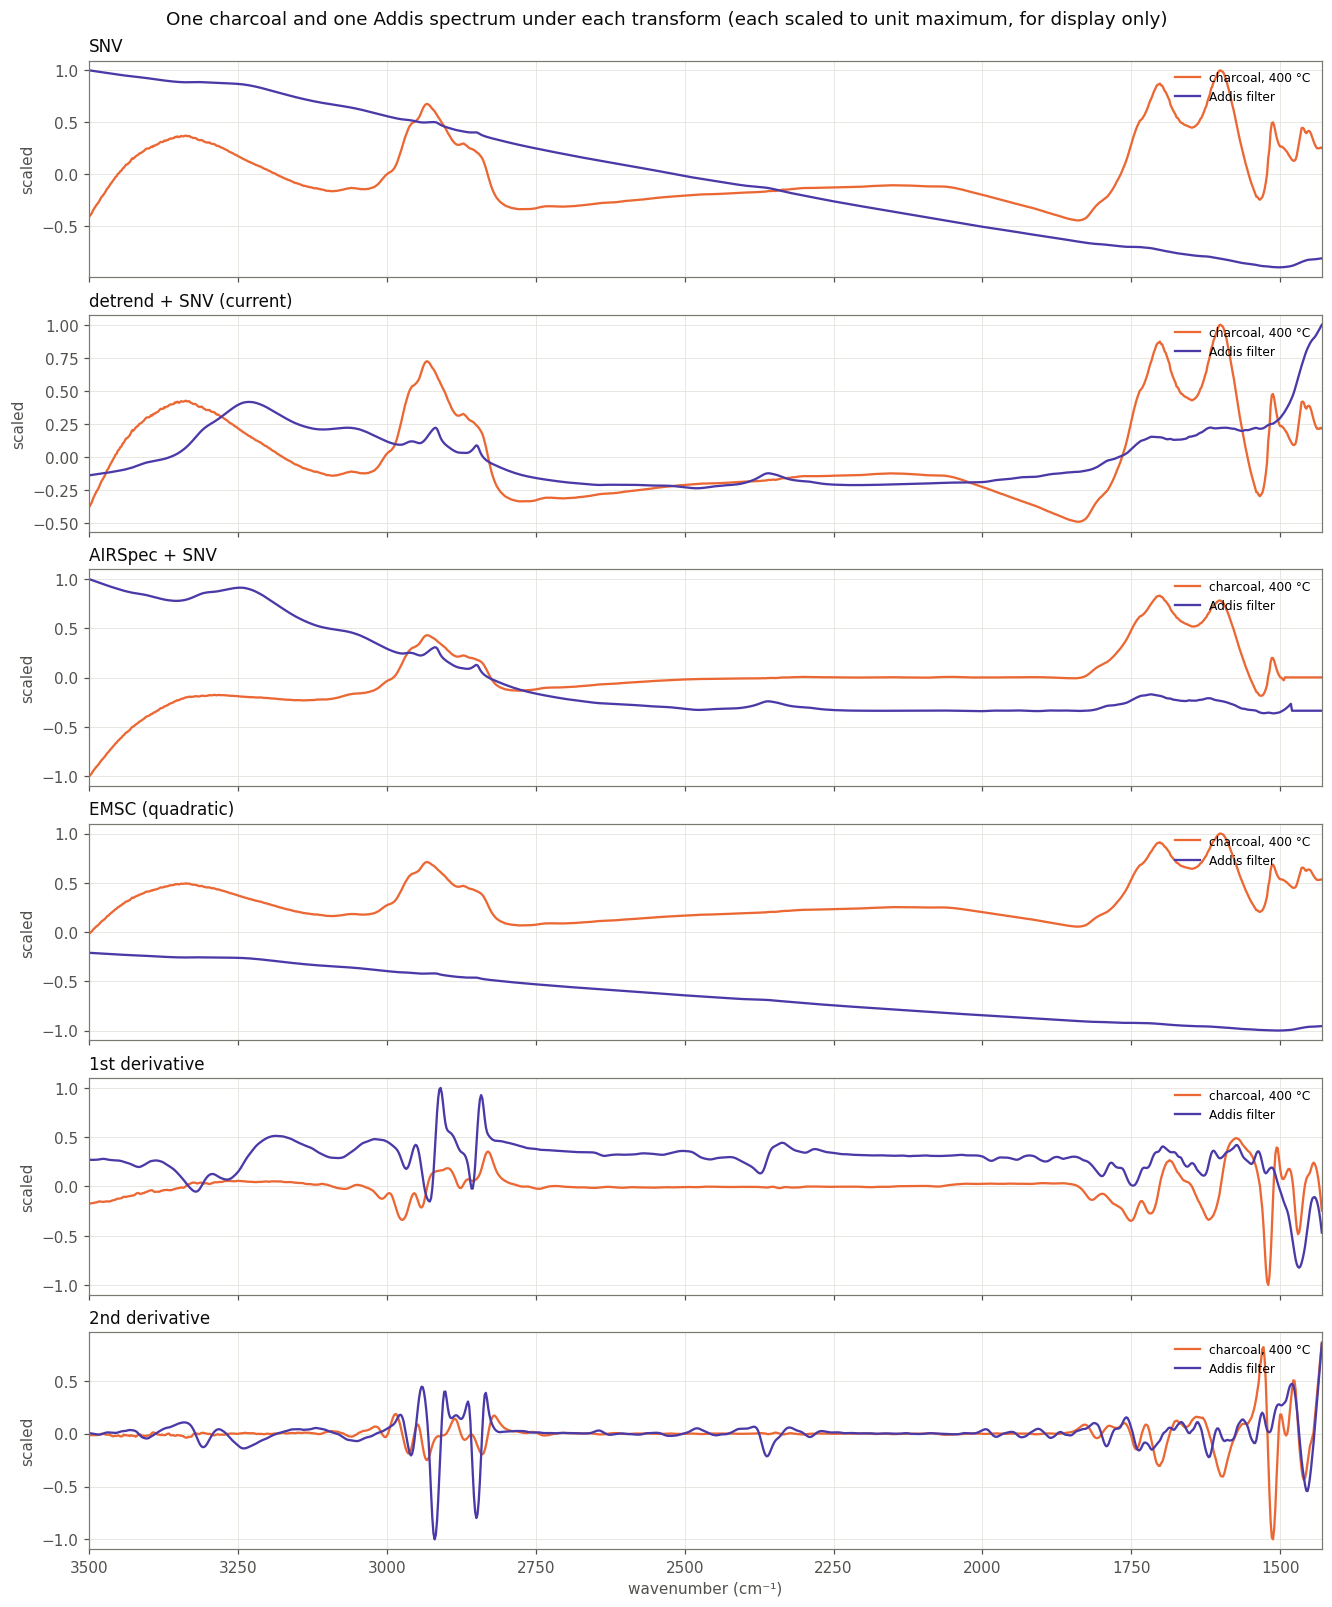

In [6]:
show = {"SNV": snv, "detrend + SNV (current)": lambda X: snv(detrend(X, GRID)),
        "AIRSpec + SNV": lambda X: snv(airspec(X)),
        "EMSC (quadratic)": emsc, "1st derivative": d1, "2nd derivative": d2}
lib_400 = X_lib[temp == 400][:200]

fig, axes = plt.subplots(len(show), 1, figsize=(12, 14.5), constrained_layout=True,
                         sharex=True)
for ax, (name, fn) in zip(axes, show.items()):
    a = fn(lib_400)[0]
    b = fn(X_addis_raw[:200])[0]
    ax.plot(GRID, a / np.abs(a).max(), color=SERIES[1], lw=1.5, label="charcoal, 400 °C")
    ax.plot(GRID, b / np.abs(b).max(), color=ADDIS_COLOR, lw=1.5, label="Addis filter")
    ax.set_title(name, color=INK, loc="left")
    ax.set_ylabel("scaled", color=INK2)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(GRID.max(), GRID.min())
axes[-1].set_xlabel("wavenumber (cm⁻¹)", color=INK2)
fig.suptitle("One charcoal and one Addis spectrum under each transform "
             "(each scaled to unit maximum, for display only)", fontsize=12, color=INK)
fig.savefig(PLOT_DIR / "01_transforms_visual.png", dpi=160, bbox_inches="tight")
plt.show()

## 3b. AIRSpec baselining — the transform this project already uses on one side

The list so far omits the treatment that matters most here. Addis spectra are
**AIRSpec-baselined** (the validated APRLssb segmented smoothing-spline port from
phase 3) before anything else happens, while the charcoal collections are used exactly
as their authors published them. That asymmetry has never been tested.

The obvious fix is to baseline both sides the same way. It runs into a hard structural
obstacle.

In [7]:
print("AIRSpec fits segment 1 between a fixed anchor at 2220 cm-1 and a search that "
      "starts at 3710 cm-1.")
print("A collection that stops below 3710 cannot support that fit as designed.\n")
cover = pd.DataFrame([
    {"collection": s.short, "max wavenumber": s.wn.max(),
     "reaches the 3710 anchor": "yes" if s.wn.max() >= 3710
     else ("marginal" if s.wn.max() >= 3700 else "NO")}
    for s in sets.values()]).set_index("collection").round(1)
display(cover)

AIRSpec fits segment 1 between a fixed anchor at 2220 cm-1 and a search that starts at 3710 cm-1.
A collection that stops below 3710 cannot support that fit as designed.



,max wavenumber,reaches the 3710 anchor
collection,,
Minatre ref,3500.3,NO
Minatre burns,3500.3,NO
Maezumi,3500.3,NO
McCall 6-feedstock,3701.0,marginal
McCall barley,4000.0,yes
Gosling,3598.7,NO


**Only one of the six collections can take a faithful AIRSpec baseline.** McCall barley
reaches 4000 cm⁻¹, McCall six-feedstock stops at 3701 (marginal), and the other four —
including Minatre, which supplies most of the library — stop at 3500–3599. The published
charcoal archive simply was not measured high enough.

What remains is a *truncated* AIRSpec, fitted on the 1430–3500 comparison window. That is
applied below and benchmarked with everything else, but its own diagnostics already warn
against it:

In [8]:
airspec_check = pd.DataFrame([
    {"spectra": "charcoal library — as published", "ramp score": ramp_score(X_lib, GRID)},
    {"spectra": "charcoal library — truncated AIRSpec",
     "ramp score": ramp_score(airspec(X_lib), GRID)},
    {"spectra": "Addis — offset-corrected only",
     "ramp score": ramp_score(X_addis_offset, GRID)},
    {"spectra": "Addis — truncated AIRSpec (on 1430–3500)",
     "ramp score": ramp_score(airspec(X_addis_offset), GRID)},
    {"spectra": "Addis — full-range AIRSpec (phase-3, on 1425–3998)",
     "ramp score": ramp_score(X_addis_full_airspec, GRID)},
]).set_index("spectra").round(3)
display(airspec_check)
airspec_check.to_csv(TABLE_DIR / "airspec_range_check.csv")

print("Two things to notice:")
print(" 1. Truncated AIRSpec OVERCORRECTS the charcoal: the residual slope flips sign")
print("    (-0.43 -> +0.51). It removes more than the baseline.")
print(" 2. Truncating hurts Addis too: the same spectra corrected on the full 1425-3998")
print("    range score +0.70, but only +0.84 when the fit is confined to 1430-3500.")
print("    AIRSpec must be run on its native range BEFORE cropping, which is what the")
print("    phase-3 cache does and what every other notebook in this folder uses.")

,ramp score
spectra,
charcoal library — as published,-0.476
charcoal library — truncated AIRSpec,0.401
Addis — offset-corrected only,0.995
Addis — truncated AIRSpec (on 1430–3500),0.837
"Addis — full-range AIRSpec (phase-3, on 1425–3998)",0.700


Two things to notice:
 1. Truncated AIRSpec OVERCORRECTS the charcoal: the residual slope flips sign
    (-0.43 -> +0.51). It removes more than the baseline.
 2. Truncating hurts Addis too: the same spectra corrected on the full 1425-3998
    range score +0.70, but only +0.84 when the fit is confined to 1430-3500.
    AIRSpec must be run on its native range BEFORE cropping, which is what the
    phase-3 cache does and what every other notebook in this folder uses.


### What the AIRSpec baseline actually does to each side

The fit itself, drawn on one representative spectrum from each side. This is the figure
that explains the numbers above: on Addis the fitted baseline tracks a genuine sloping
background, while on charcoal it cuts through real band structure.

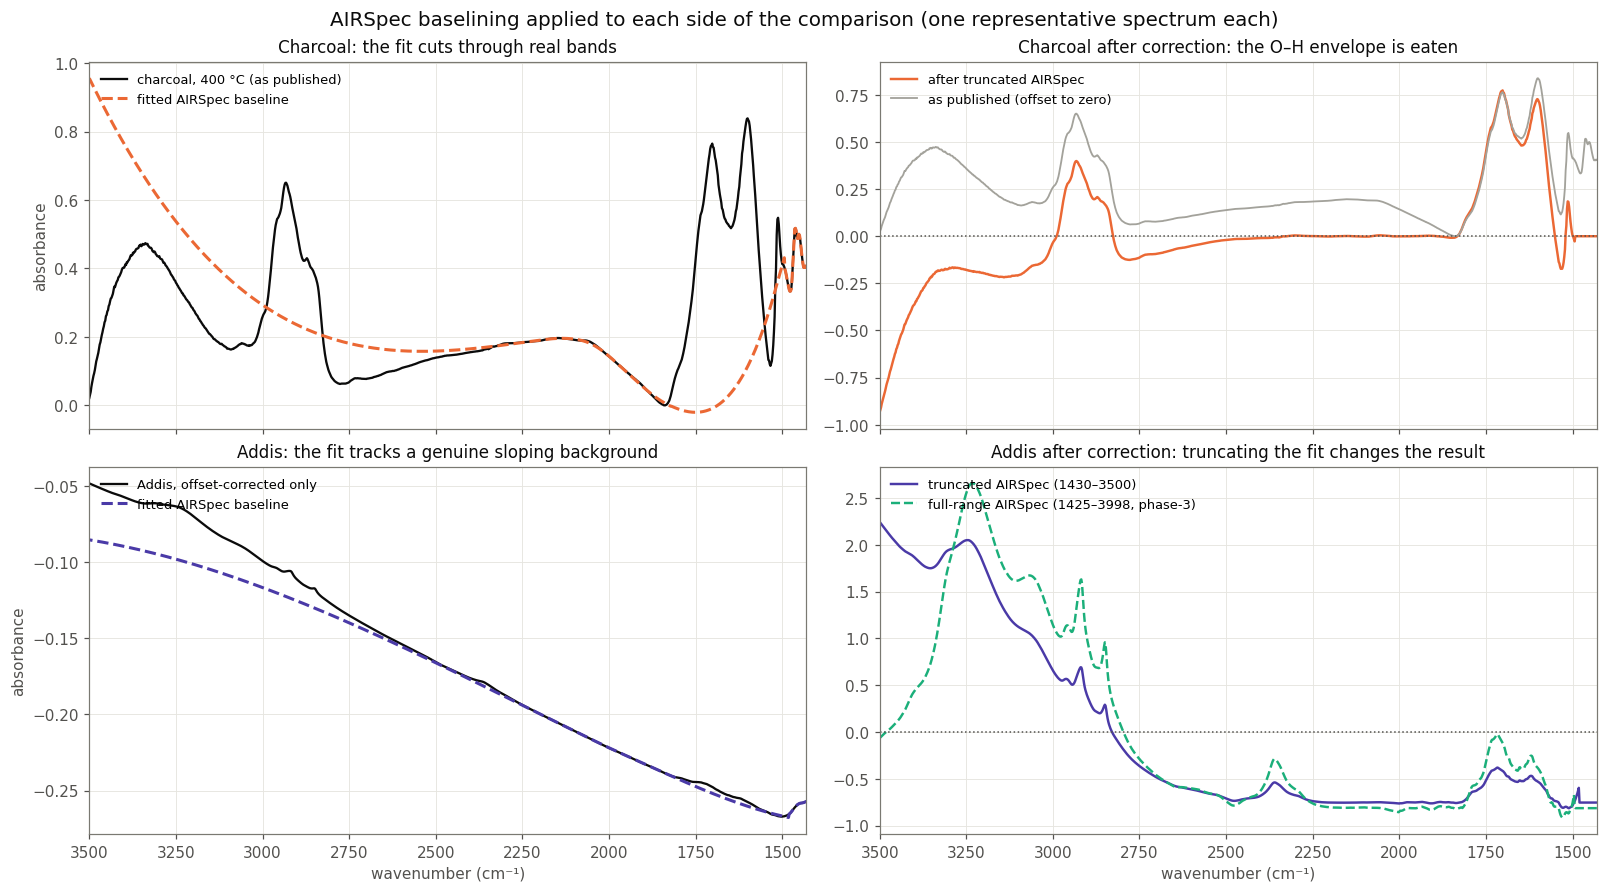

In [9]:
char_one = X_lib[temp == 400][:120]
addis_one = X_addis_offset[:120]
base_c, corr_c = airspec_parts(char_one)
base_a, corr_a = airspec_parts(addis_one)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 8), constrained_layout=True, sharex=True)

ax = axes[0, 0]
ax.plot(GRID, char_one[0], color=INK, lw=1.5, label="charcoal, 400 °C (as published)")
ax.plot(GRID, base_c[0], color=SERIES[1], lw=2.0, ls="--", label="fitted AIRSpec baseline")
ax.set_ylabel("absorbance", color=INK2)
ax.set_title("Charcoal: the fit cuts through real bands", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[0, 1]
ax.plot(GRID, corr_c[0], color=SERIES[1], lw=1.6, label="after truncated AIRSpec")
ax.plot(GRID, char_one[0] - char_one[0].min(), color=MUTED, lw=1.2,
        label="as published (offset to zero)")
ax.axhline(0, color=INK2, lw=1, ls=":")
ax.set_title("Charcoal after correction: the O–H envelope is eaten", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1, 0]
ax.plot(GRID, addis_one[0], color=INK, lw=1.5, label="Addis, offset-corrected only")
ax.plot(GRID, base_a[0], color=ADDIS_COLOR, lw=2.0, ls="--", label="fitted AIRSpec baseline")
ax.set_ylabel("absorbance", color=INK2)
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_title("Addis: the fit tracks a genuine sloping background", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1, 1]
ax.plot(GRID, snv(corr_a)[0], color=ADDIS_COLOR, lw=1.6,
        label="truncated AIRSpec (1430–3500)")
ax.plot(GRID, snv(X_addis_full_airspec[:120])[0], color=SERIES[2], lw=1.6, ls="--",
        label="full-range AIRSpec (1425–3998, phase-3)")
ax.axhline(0, color=INK2, lw=1, ls=":")
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_title("Addis after correction: truncating the fit changes the result", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

for ax in axes.ravel():
    ax.set_xlim(GRID.max(), GRID.min())
fig.suptitle("AIRSpec baselining applied to each side of the comparison "
             "(one representative spectrum each)", fontsize=13, color=INK)
fig.savefig(PLOT_DIR / "01b_airspec_fit.png", dpi=160, bbox_inches="tight")
plt.show()

The left column is the whole story. On the Addis filter the fitted baseline is a smooth
sloping curve running *underneath* the bands — exactly what a scattering background looks
like, and removing it leaves the spectrum intact. On the charcoal spectrum the same fit
rides up through the absorption envelope itself, because with no data above 3500 cm⁻¹ the
segment-1 anchor has nothing to hold onto. Subtracting it removes chemistry, which is why
the temperature silhouette goes negative in the benchmark below.

## 4. An objective benchmark

"Better" needs a criterion that never looks at Addis, or the choice gets tuned to the
answer. Two label-based criteria, both computed on charcoal only:

* **Cross-collection temperature recovery.** Hold out one collection, match its spectra
  against the others, read off the implied temperature. A transform that removes
  laboratory and sample-presentation effects while preserving chemistry should recover
  temperature *across* a lab boundary — which is exactly the bulk-to-filter
  generalization this project needs.
* **Separability.** Silhouette of the collection label (**lower is better** — the
  laboratory should not be the dominant structure) against silhouette of the temperature
  tier (**higher is better** — chemistry should be).

In [10]:
ALL_METHODS = {"SNV": snv, **NON_AFFINE}

rows = []
for name, fn in ALL_METHODS.items():
    Z = fn(X_lib)
    if not np.isfinite(Z).all():
        print(f"skipping {name}: non-finite output")
        continue
    errs = []
    for c in np.unique(coll):
        te = coll == c
        R = corr(Z[te], Z[~te])
        idx = np.argsort(-R, axis=1)[:, :25]
        errs.append(np.abs(np.median(temp[~te][idx], axis=1) - temp[te]))
    err = np.concatenate(errs)

    P = PCA(n_components=10, random_state=RANDOM_SEED).fit_transform(zrows(Z))
    s = rng.choice(len(P), 1500, replace=False)
    rows.append({
        "transform": name,
        "MAE (°C)": err.mean(),
        "% within 100 °C": 100 * (err <= 100).mean(),
        "sil(collection) ↓": silhouette_score(P[s], coll[s]),
        "sil(temperature) ↑": silhouette_score(P[s], temp[s].astype(int)),
        "ramp score": ramp_score(Z, GRID),
    })
bench = pd.DataFrame(rows).set_index("transform").round(3)
display(bench)
bench.to_csv(TABLE_DIR / "benchmark.csv")

,MAE (°C),% within 100 °C,sil(collection) ↓,sil(temperature) ↑,ramp score
transform,,,,,
SNV,103.889,76.752,0.123,0.021,-0.472
detrend + SNV (current),116.517,67.308,0.138,0.051,0.000
AIRSpec + SNV,213.355,33.974,0.103,-0.278,0.239
AIRSpec + detrend + SNV,203.397,32.949,0.158,-0.270,-0.000
EMSC (quadratic),153.483,45.726,0.264,0.044,-0.462
1st derivative,145.150,48.077,0.142,0.176,0.115
2nd derivative,166.538,50.983,0.132,0.157,-0.044
2nd derivative + SNV,166.538,50.983,0.133,0.160,-0.014


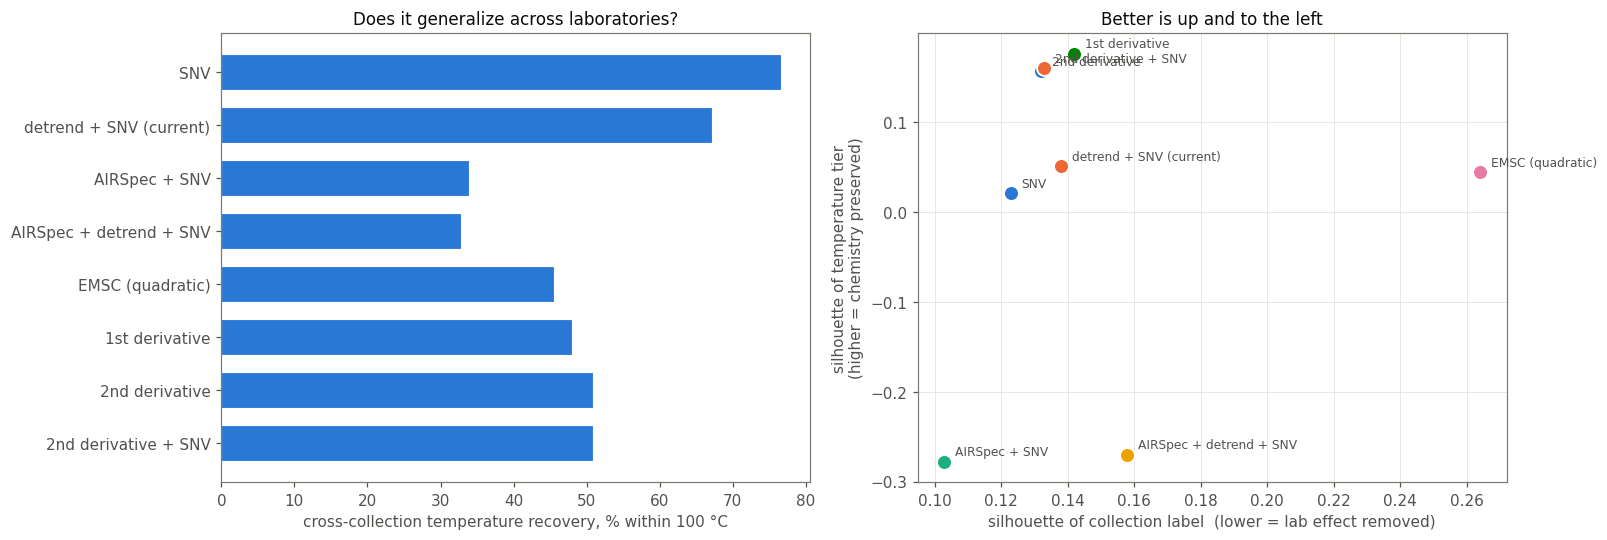

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), constrained_layout=True)
order = bench.index.tolist()
ypos = np.arange(len(order))

ax = axes[0]
ax.barh(ypos, bench.loc[order, "% within 100 °C"], color=SERIES[0], height=0.7,
        edgecolor="white", linewidth=1.4)
ax.set_yticks(ypos); ax.set_yticklabels(order)
ax.set_xlabel("cross-collection temperature recovery, % within 100 °C", color=INK2)
ax.set_title("Does it generalize across laboratories?", color=INK)
ax.grid(False); ax.invert_yaxis()

ax = axes[1]
for i, (name, row) in enumerate(bench.iterrows()):
    ax.scatter(row["sil(collection) ↓"], row["sil(temperature) ↑"], s=95,
               c=SERIES[i % len(SERIES)], edgecolor="white", linewidth=1.2, zorder=3)
    ax.annotate(name, (row["sil(collection) ↓"], row["sil(temperature) ↑"]),
                xytext=(7, 4), textcoords="offset points", fontsize=8, color=INK2)
ax.set_xlabel("silhouette of collection label  (lower = lab effect removed)", color=INK2)
ax.set_ylabel("silhouette of temperature tier\n(higher = chemistry preserved)", color=INK2)
ax.set_title("Better is up and to the left", color=INK)

fig.savefig(PLOT_DIR / "02_benchmark.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. What each choice does to the Addis conclusion

The benchmark says which transform generalizes best charcoal-to-charcoal. This says
whether it changes the answer the project actually cares about.

**Read the correlation column with suspicion.** Every transform here is applied
symmetrically to both sides starting from offset-corrected Addis spectra, so these
numbers are not directly comparable with `char_02` — the last row gives the asymmetric
combination the rest of the folder actually uses (full-range AIRSpec on Addis, charcoal
as published), which is the number to compare against.

In [12]:
rows = []
for name, fn in ALL_METHODS.items():
    Z, Za = fn(X_lib), fn(X_addis_raw)
    if not np.isfinite(Z).all():
        continue
    R = corr(Za, Z)
    idx = np.argsort(-R, axis=1)[:, :25]
    implied = np.median(temp[idx], axis=1)
    modal = pd.Series(implied).mode().iloc[0]
    rows.append({
        "transform": name,
        "median best r": np.median(R.max(axis=1)),
        "modal implied T (°C)": modal,
        "share at modal T": (implied == modal).mean(),
        "best match is the 0 °C tier": (temp[idx[:, 0]] == 0).mean(),
    })
# The asymmetric combination the rest of the folder actually uses, for reference:
# full-range AIRSpec on Addis only, charcoal as published, then detrend + SNV on both.
Zc = snv(detrend(X_lib, GRID))
Za = snv(detrend(X_addis_full_airspec, GRID))
R = corr(Za, Zc)
idx = np.argsort(-R, axis=1)[:, :25]
implied = np.median(temp[idx], axis=1)
modal = pd.Series(implied).mode().iloc[0]
rows.append({
    "transform": "PROJECT DEFAULT (full-range AIRSpec on Addis only)",
    "median best r": np.median(R.max(axis=1)),
    "modal implied T (°C)": modal,
    "share at modal T": (implied == modal).mean(),
    "best match is the 0 °C tier": (temp[idx[:, 0]] == 0).mean(),
})

addis_tab = pd.DataFrame(rows).set_index("transform").round(3)
display(addis_tab)
addis_tab.to_csv(TABLE_DIR / "addis_conclusion_by_transform.csv")

n_zero = int((temp == 0).sum())
print(f"The 0 °C (unburned) tier holds only {n_zero} of the {len(temp):,} library "
      f"spectra ({100*n_zero/len(temp):.1f} %).")
print("A transform that sends nearly every Addis filter there is not so much agreeing")
print("with char_05 as collapsing onto the smallest class — the failure mode char_03 found.")

,median best r,modal implied T (°C),share at modal T,best match is the 0 °C tier
transform,,,,
SNV,0.564,300.0,1.000,0.996
detrend + SNV (current),0.878,400.0,0.515,0.000
AIRSpec + SNV,0.993,200.0,0.548,0.088
AIRSpec + detrend + SNV,0.978,300.0,0.490,0.067
EMSC (quadratic),0.014,800.0,1.000,0.000
1st derivative,0.653,150.0,0.766,0.389
2nd derivative,0.773,150.0,0.967,0.870
2nd derivative + SNV,0.773,150.0,0.967,0.870
PROJECT DEFAULT (full-range AIRSpec on Addis only),0.777,400.0,0.979,0.004


The 0 °C (unburned) tier holds only 24 of the 2,340 library spectra (1.0 %).
A transform that sends nearly every Addis filter there is not so much agreeing
with char_05 as collapsing onto the smallest class — the failure mode char_03 found.


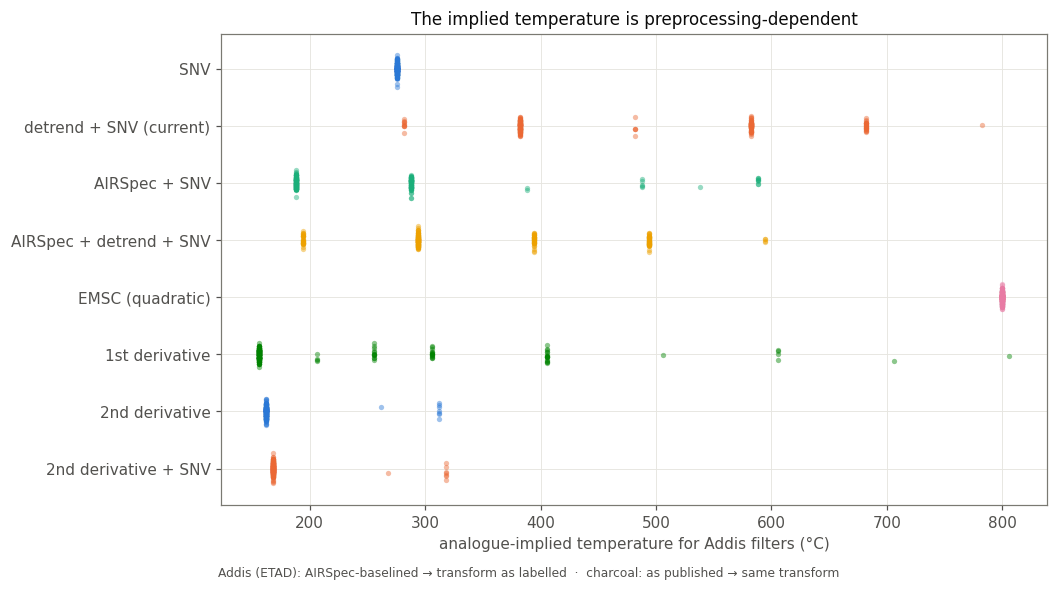

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 5), constrained_layout=True)
for i, (name, fn) in enumerate(ALL_METHODS.items()):
    Z, Za = fn(X_lib), fn(X_addis_raw)
    if not np.isfinite(Z).all():
        continue
    R = corr(Za, Z)
    idx = np.argsort(-R, axis=1)[:, :25]
    implied = np.median(temp[idx], axis=1)
    jitter = (i - len(ALL_METHODS) / 2) * 6
    ax.scatter(implied + jitter, np.full(len(implied), i) + rng.normal(0, 0.08, len(implied)),
               s=12, c=SERIES[i % len(SERIES)], alpha=0.45, linewidth=0)
ax.set_yticks(range(len(ALL_METHODS)))
ax.set_yticklabels(list(ALL_METHODS))
ax.set_xlabel("analogue-implied temperature for Addis filters (°C)", color=INK2)
ax.set_title("The implied temperature is preprocessing-dependent", color=INK)
ax.invert_yaxis()
fig.text(0.5, -0.02, "Addis (ETAD): AIRSpec-baselined → transform as labelled  ·  "
         "charcoal: as published → same transform", ha="center", va="top",
         fontsize=8, color=INK2)
fig.savefig(PLOT_DIR / "03_implied_temperature.png", dpi=160, bbox_inches="tight")
plt.show()

## Takeaways

- **Most of the alternatives are not alternatives.** Under Pearson correlation — the
  metric every analogue-matching result in this folder uses — SNV, vector (L2), area,
  band normalization and even *no normalization at all* produce identical correlation
  matrices, agreeing to **~8×10⁻¹⁶**. Correlation is invariant to per-spectrum offset and
  positive scaling, and that is all these methods do. Swapping SNV for any of them would
  change nothing. (MSC is the near-miss: its scale factor goes negative for 51 of 2,100
  Minatre spectra, flipping their sign — a reason to avoid it, not to prefer it.)
- **The choice does matter for distance-based results.** Euclidean distances under band
  normalization correlate only **0.64** with SNV distances. So the correlation-based
  conclusions are immune to the normalization choice, but **`char_02`'s Mahalanobis
  distance and PCA score space are not** — a qualifier that was missing when they were
  first reported.
- **AIRSpec cannot be applied to the charcoal side, and forcing it is actively harmful.**
  Its segment-1 fit anchors at 3710 cm⁻¹; **only McCall barley (4000 cm⁻¹) reaches that**,
  McCall six-feedstock is marginal at 3701, and the other four collections — including
  Minatre, which supplies most of the library — stop at 3500–3599. A truncated AIRSpec
  fitted on 1430–3500 *overcorrects*: the charcoal residual slope flips sign
  (**−0.48 → +0.40**), cross-collection temperature recovery collapses from **77 % to
  34 %**, and the temperature silhouette goes **negative** (−0.28) — temperature tiers end
  up worse than randomly separated. It removes the chemistry along with the baseline.
- **The transform that maximizes Addis–charcoal correlation is the one that destroys the
  most chemistry**, and that is the most useful thing in this notebook. Truncated
  AIRSpec on both sides gives the highest correlation of anything tested
  (**r = 0.993**) while scoring worst on every objective measure. Both sides get
  flattened into a similar smooth residual and correlate beautifully for reasons that
  have nothing to do with composition. Any preprocessing chosen by "which one makes Addis
  match best" would have selected exactly this.
- **AIRSpec must also be run on its native range before cropping.** The same Addis
  spectra score a ramp of **+0.70** when corrected on the full 1425–3998 range but
  **+0.84** when the fit is confined to 1430–3500. The phase-3 cache does it correctly;
  this is a reason to keep using that cache rather than re-fitting on a comparison window.
- **Nothing beats SNV on the objective test.** Cross-collection temperature recovery
  ranks: plain SNV **76.8 %** within 100 °C, detrend + SNV **67.3 %**, 2nd derivative
  **51.0 %**, 1st derivative **48.1 %**, EMSC **45.7 %**, truncated AIRSpec **34.0 %**.
  Derivatives raise the temperature silhouette roughly eight-fold but degrade cross-lab
  recovery and send most Addis filters' best match to the 24-spectrum 0 °C tier — the
  collapse-onto-the-smallest-class failure `char_03` diagnosed.

**Recommendation: keep the current chain, and keep it asymmetric.** Full-range AIRSpec on
the Addis side only (because only Addis was measured over the range AIRSpec needs),
charcoal as published, then linear detrend and SNV on both. The asymmetry is not an
oversight to be corrected — it is forced by what the published archive covers, and the
symmetric alternative is measurably worse.

**One caveat on the detrend step.** This benchmark is charcoal-only, and on it plain SNV
beats detrend + SNV (76.8 % vs 67.3 %). That is not a reason to drop the detrend: it
exists because Addis and charcoal carry residual slopes of *opposite sign* (+0.70 vs
−0.48), and a charcoal-only test cannot see that mismatch. Detrending trades a little
charcoal-to-charcoal accuracy for Addis-to-charcoal comparability — the trade this project
wants, but worth knowing about. Both are reported throughout and agree on every
conclusion that matters.